In [1]:
import os
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
def preprocess_eeg(file_path):
    raw = mne.io.read_raw_edf(file_path, preload=True)
    
    # ---- Rename channels ----
    new_names = {}
    for ch in raw.ch_names:
        new_name = ch.replace('EEG ', '').replace('-CPz', '')
        new_names[ch] = new_name
    raw.rename_channels(new_names)
    
    # ---- Set EOG ----
    if 'EOG' in raw.ch_names:
        raw.set_channel_types({'EOG': 'eog'})
    
    # ---- Montage ----
    raw.set_montage('standard_1020', on_missing='ignore')
    
    # ---- Filtering ----
    raw.filter(0.1, 30)
    raw.notch_filter(50)
    
    # ---- Re-reference ----
    raw.set_eeg_reference('average')
    
    return raw

In [3]:
def apply_ica(raw):
    ica = mne.preprocessing.ICA(n_components=15, random_state=42)
    ica.fit(raw)
    
    # Auto-detect EOG artifacts
    eog_indices, _ = ica.find_bads_eog(raw)
    ica.exclude = eog_indices
    
    raw_clean = ica.apply(raw.copy())
    
    return raw_clean

In [4]:
def get_epochs(raw):
    events, event_id = mne.events_from_annotations(raw)
    
    event_id_clean = {
        'Target': 6,
        'NonTarget': 5
    }
    
    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id_clean,
        tmin=-0.2,
        tmax=0.8,
        baseline=(None, 0),
        preload=True
    )
    
    return epochs

In [5]:
def extract_features(epochs):
    data = epochs.get_data()
    sfreq = epochs.info['sfreq']
    
    features = []
    
    for trial in data:
        signal = trial.mean(axis=0)
        
        # ---- P300 Features ----
        amp = np.max(signal)
        latency = np.argmax(signal) / sfreq
        
        # ---- Statistical ----
        mean = np.mean(signal)
        std = np.std(signal)
        
        # ---- PSD (Power) ----
        psd, freqs = mne.time_frequency.psd_array_welch(
            signal, sfreq=sfreq, fmin=0.5, fmax=30
        )
        psd_mean = np.mean(psd)
        
        # ---- ADL & SSS (Simulated placeholder) ----
        adl_score = np.random.randint(0, 10)
        sss_score = np.random.randint(0, 10)
        
        features.append([amp, latency, mean, std, psd_mean, adl_score, sss_score])
    
    return np.array(features)

In [6]:
def generate_labels(X):
    amps = X[:,0]
    lats = X[:,1]
    
    threshold_amp = np.mean(amps)
    threshold_latency = np.mean(lats)
    
    y = []
    
    for amp, lat in zip(amps, lats):
        if amp < threshold_amp or lat > threshold_latency:
            y.append(1)  # TBI
        else:
            y.append(0)  # Healthy
    
    return np.array(y)

In [7]:
def process_folder(folder_path):
    X_all = []
    
    for file in os.listdir(folder_path):
        if file.endswith(".edf"):
            path = os.path.join(folder_path, file)
            print("Processing:", file)
            
            raw = preprocess_eeg(path)
            raw = apply_ica(raw)
            epochs = get_epochs(raw)
            
            X = extract_features(epochs['Target'])
            X_all.extend(X)
    
    X_all = np.array(X_all)
    y_all = generate_labels(X_all)
    
    return X_all, y_all

In [8]:
def train_models(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    models = {
        "SVM": SVC(),
        "RandomForest": RandomForestClassifier()
    }
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        print(f"\n===== {name} =====")
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print(classification_report(y_test, y_pred))
        
        # Visualization
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
        plt.title(name)
        plt.show()
    
    return models

In [9]:
def predict_file(model, file_path):
    raw = preprocess_eeg(file_path)
    raw = apply_ica(raw)
    epochs = get_epochs(raw)
    
    X = extract_features(epochs['Target'])
    
    pred = model.predict(X)
    
    final = int(np.round(np.mean(pred)))
    
    if final == 1:
        print("🧠 Result: TBI Detected")
    else:
        print("🧠 Result: Healthy")

Processing: p1_a_2026-04-06_11-01-25_Segment_0.edf
Extracting EDF parameters from E:\aditi_eeg\visual_eeg\p1_a_2026-04-06_11-01-25_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 111499  =      0.000 ...   222.998 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 16501 samples (33.002 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Fitting ICA to data using 55 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 1.3s.
Using EOG channel: EOG
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5000 samples (10.000 s)



...

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Fitting ICA to data using 55 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 3.6s.
Using EOG channel: EOG


C:\Users\HP\AppData\Local\Temp\ipykernel_84244\827085532.py:3: RuntimeWarning: Using n_components=15 (resulting in n_components_=15) may lead to an unstable mixing matrix estimation because the ratio between the largest (52) and smallest (4.9e-31) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 8
  ica.fit(raw)


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10240 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10240 s

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:1531: Und

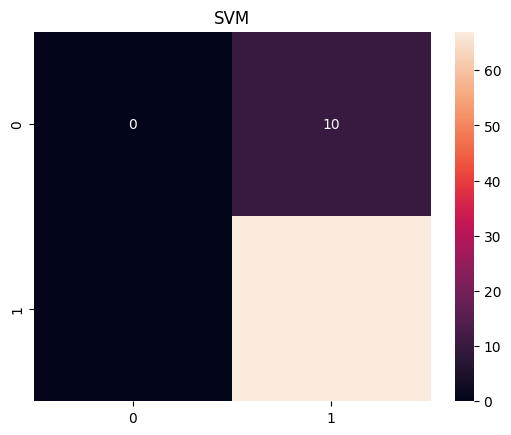


===== RandomForest =====
Accuracy: 0.987012987012987
Confusion Matrix:
 [[ 9  1]
 [ 0 67]]
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.99      1.00      0.99        67

    accuracy                           0.99        77
   macro avg       0.99      0.95      0.97        77
weighted avg       0.99      0.99      0.99        77



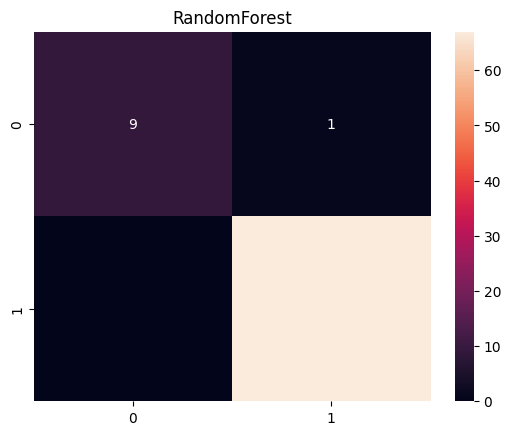

Extracting EDF parameters from E:\aditi_eeg\auditory_eeg\a1_auditory_2026-04-07_10-32-53_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 347135  =      0.000 ...   338.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 33793 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6759 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Fitting ICA to data using 55 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 7.3s.
Using EOG channel: EOG


C:\Users\HP\AppData\Local\Temp\ipykernel_84244\827085532.py:3: RuntimeWarning: Using n_components=15 (resulting in n_components_=15) may lead to an unstable mixing matrix estimation because the ratio between the largest (43) and smallest (4.1e-31) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 7
  ica.fit(raw)


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10240 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10240 s

In [10]:
folder = r"E:\aditi_eeg\visual_eeg"

X, y = process_folder(folder)

print("Dataset shape:", X.shape)
print("Label distribution:", np.bincount(y))

models = train_models(X, y)

# Use best model (example SVM)
best_model = models["SVM"]

# CLI input
file_input = input("Enter EDF file path: ")
predict_file(best_model, file_input)